In [1]:
import os
import sys
import datetime
import pandas as pd
import pytrends
from pytrends.request import TrendReq
print("Dattime= {0}".format(datetime.datetime.now()))

Dattime= 2020-10-20 19:28:04.672564


In [2]:
pytrends = TrendReq(hl='en-US', tz=360)
kw_list = [  "work from home",  "unemployment", "indeed jobs", "work"]
# "unemployment", "job" " ui online"
#,'hire', "Jobs", "vacancy", "employment", "unemployment", "benefits"] "njuifile"
nweeks = 200
end_date = datetime.date.today().strftime("%Y-%m-%d")
start_date = (datetime.date.today() - datetime.timedelta(weeks=nweeks)).strftime("%Y-%m-%d")
timeframe = start_date+ " " + end_date  
print(timeframe)
geo = 'US'
pytrends.build_payload(kw_list, cat=60, timeframe=timeframe, geo=geo, gprop='')

2016-12-20 2020-10-20


In [3]:
df = pytrends.interest_over_time()


<AxesSubplot:xlabel='date'>

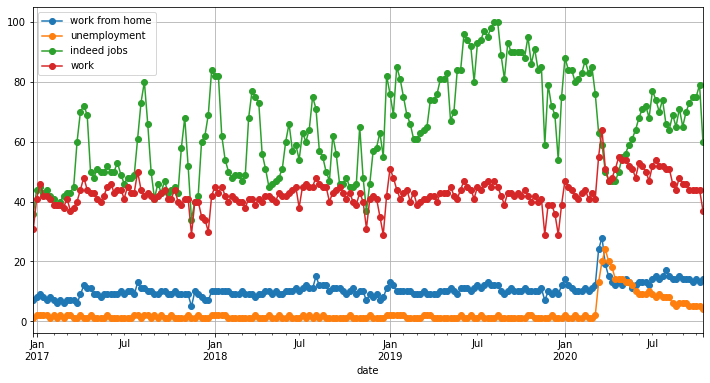

In [4]:
df.plot(figsize=[12,6], grid=True, marker='o')

In [5]:
pytrends.suggestions("job")

[{'mid': '/m/04115t2', 'title': 'Job', 'type': 'Topic'},
 {'mid': '/m/07s_c', 'title': 'Unemployment', 'type': 'Topic'},
 {'mid': '/m/01rbb', 'title': 'Crime', 'type': 'Topic'},
 {'mid': '/m/019323', 'title': 'Duty', 'type': 'Topic'},
 {'mid': '/g/1211q_qf', 'title': 'job', 'type': 'Topic'}]

In [6]:
dir(pytrends)
related = pytrends.related_queries()
related.keys()

dict_keys(['work from home', 'unemployment', 'indeed jobs', 'work'])

In [7]:
from collections import deque
import time

def build_payload(pytrends, kw, nweeks=100, geo='US', cat=60):
    end_date = datetime.date.today()
    start_date = datetime.date.today() - datetime.timedelta(weeks=nweeks)
    timeframe = start_date.strftime("%Y-%m-%d") + " " + end_date.strftime("%Y-%m-%d")  
    pytrends.build_payload([kw], cat=cat, timeframe=timeframe, geo=geo, gprop='')    
    return pytrends

sleeptime = 0.25
verbosity=1
max_keywords = 100
min_score = 80

keywords2try = deque()
keyword_tups = deque()
keyword_set = set()

# seed the queue with a few terms
keywords2try.appendleft(("jobs", 101, 0, 'root', 101))
keywords2try.appendleft(("unemployment", 101, 0, 'root', 101))

while len(keywords2try) > 0:
    if len(keyword_tups) > max_keywords:
        break
    kw, score, level, parent, parent_score = keywords2try.pop()
    if kw in keyword_set:
        if verbosity > 1:
            print("{0} already in set".format(kw))
        continue
    if verbosity > 0:
        print("Adding kw: {0}".format(kw))
    # add to keyword_tups and keyword_set
    keyword_tups.appendleft((kw, score, level, parent, parent_score))
    keyword_set.add(kw)
    pytrends = TrendReq(hl='en-US', tz=360)    
    pytrends = build_payload(pytrends, kw)
    time.sleep(.5)
    related = pytrends.related_queries()
    if not related:
        if verbosity > 1:
            print("\t No related")
        continue
    if 'top' not in related[kw].keys():
        if verbosity > 1:
            print("\tNo top")
        continue
    df = related[kw]['top']
    if df is None:
        if verbosity > 1:
            print("\ttop is empty")
        continue
    for tup in df.itertuples():
        child_score = score * tup.value/float(100)
        if child_score > min_score and tup.query not in keyword_set:
            print("\tpushing {0}".format(tup.query))
            keywords2try.appendleft((tup.query, child_score, level+1, kw, score))
print("done")
kw_df = pd.DataFrame(data=list(keyword_tups), columns=['keyword', 'score', 'level','parent', 'parent_score']).sort_values(by="score", ascending=False)
kw_df.head()

Adding kw: jobs
	pushing jobs near
	pushing jobs near me
Adding kw: unemployment
	pushing unemployment jobs
	pushing unemployment part time
Adding kw: jobs near
	pushing jobs near me
Adding kw: jobs near me
	pushing jobs near me hiring
Adding kw: unemployment jobs
	pushing florida unemployment
	pushing unemployment rate
	pushing unemployment benefits
	pushing unemployment office
Adding kw: unemployment part time
	pushing unemployment for part time
Adding kw: jobs near me hiring
	pushing part time jobs hiring near me
	pushing part time jobs near me hiring
	pushing hiring near me part time
Adding kw: florida unemployment
	pushing careersource
Adding kw: unemployment rate
Adding kw: unemployment benefits
	pushing part time unemployment benefits
Adding kw: unemployment office
	pushing unemployment office near me
Adding kw: unemployment for part time
	pushing unemployment for part time workers
	pushing can part time file for unemployment
	pushing unemployment for part time employees
Adding 

,keyword,score,level,parent,parent_score
42,jobs,101.0,0,root,101.0
13,florida careersource,101.0,4,careersource,101.0
2,careersource central florida,101.0,5,florida careersource,101.0
41,unemployment,101.0,0,root,101.0
40,jobs near,101.0,1,jobs,101.0


In [20]:
print("Found {0} queries".format(kw_df.shape[0]))
kw_df.sort_values(by="score", inplace=True)
kw_df.write_csv("google_keywords.csv")

Found 31 queries


,keyword,score,level,parent,parent_score
22,unemployment office,90.900000,2,unemployment jobs,101.000000
16,unemployment office near me,90.900000,3,unemployment office,90.900000
0,jobs part time near me,91.229664,5,part time jobs,91.229664
7,part time jobs,91.229664,4,hiring near me part time,94.051200
1,jobs near me part time hiring,91.248474,5,part time jobs hiring,93.110688
8,jobs near me part time,92.170176,4,hiring near me part time,94.051200
9,hiring part time jobs near me,92.170176,4,hiring near me part time,94.051200
4,can part time employees file for unemployment,92.920000,4,can part time file for unemployment,92.920000
5,do part time workers qualify for unemployment,92.920000,4,unemployment for part time workers,92.920000
14,can part time file for unemployment,92.920000,3,unemployment for part time,92.920000


In [11]:
keyword_tups[0]

('careersource central florida', 'florida careersource', 100)